In [16]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
import torch
from gph import ripser_parallel
from gtda.homology._utils import _postprocess_diagrams
from gtda.plotting import plot_diagram
from homology import calculate_betti_numbers, geodesic_distance_matrix
from matrepr import mprint
from sklearn.decomposition import PCA
from torch import nn
from torch.utils.data import Subset

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
target_class = 0

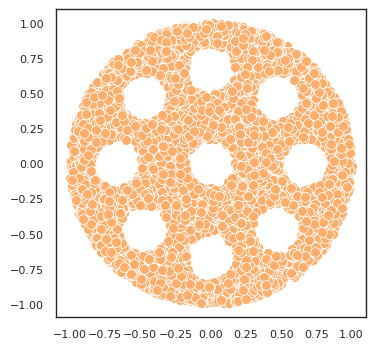

In [18]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="SunflowerDataset",
    num_samples=8_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
train_dataset = DatasetClass(config=dataset_config)

# Figure and plot
fig, ax = plt.subplots()
labels = [target_class]
colors = [
    aesthetics.SeabornColors.orange,
    aesthetics.SeabornColors.blue,
]
for i, label in enumerate(labels):
    sns.scatterplot(
        x=train_dataset.features[train_dataset.labels.squeeze() == label, 0].numpy(),
        y=train_dataset.features[train_dataset.labels.squeeze() == label, 1].numpy(),
        ax=ax,
        color=colors[i],
        marker="o",
        s=50,
    )

plt.show()

In [19]:
file_path = "/home/nsa325/work/nnscaling/model_saves/sunflower_model.safetensors"
model = MLP.load_model(file_path).eval()

{'config': '[10, 8, 6, 3]', 'dataset': 'SunflowerDataset', 'nonlinearity': 'relu', 'out_features': '2'}


Batch of class data

In [20]:
idx = torch.where(train_dataset.labels == target_class)[0]
subset = Subset(train_dataset, idx)
loader = torch.utils.data.DataLoader(subset, batch_size=2_000, shuffle=True)
data, labels = next(iter(loader))

In [21]:
# def replace_relu_with_gelu(module):
#     for name, child in module.named_children():
#         # Recursively apply the function to sub-modules
#         replace_relu_with_gelu(child)
#         # If the child module is ReLU, replace it with GELU
#         if isinstance(child, nn.ReLU):
#             setattr(module, name, nn.GELU())


# replace_relu_with_gelu(model)

In [22]:
model.hook_model()

In [23]:
_ = model.forward(data)
act_dict = model.get_activations()

In [24]:
model.summary()

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (_features)                 --
|    + LinearLayer (0)                   --
|    |    + Linear (linear)              30
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (1)                   --
|    |    + Linear (linear)              88
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (2)                   --
|    |    + Linear (linear)              54
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (3)                   --
|    |    + Linear (linear)              21
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (4)                   --
|    |    + Linear (linear)              8
Total params: 201
Trainable params: 201
Non-trainable params: 0

Initial

In [25]:
maxdim = 1
k = 10
threshold = 4

In [26]:
distance_matrix = geodesic_distance_matrix(data, k_neighbors=k)
mprint(distance_matrix)
dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

<2000×2000, 4000000 'float64' elements, array>
          0        1        2        3           1997     1998     1999
     ┌                                                                    ┐
   0 │ 0.0000   23.0000  11.0000  15.0000  ...  7.0000   24.0000  5.0000  │
   1 │ 23.0000  0.0000   31.0000  16.0000  ...  24.0000  13.0000  27.0000 │
   2 │ 11.0000  31.0000  0.0000   25.0000  ...  17.0000  34.0000  10.0000 │
   3 │ 15.0000  16.0000  25.0000  0.0000   ...  11.0000  10.0000  16.0000 │
   4 │ 12.0000  20.0000  22.0000  7.0000   ...  6.0000   16.0000  12.0000 │
     │    :        :        :        :     ...     :        :        :    │
1995 │ 10.0000  26.0000  9.0000   23.0000  ...  16.0000  31.0000  12.0000 │
1996 │ 11.0000  31.0000  1.0000   25.0000  ...  17.0000  34.0000  10.0000 │
1997 │ 7.0000   24.0000  17.0000  11.0000  ...  0.0000   21.0000  7.0000  │
1998 │ 24.0000  13.0000  34.0000  10.0000  ...  21.0000  0.0000   26.0000 │
1999 │ 5.0000   27.0000  10.0000  16.0000  ..

In [27]:
pca = PCA(n_components=2).fit_transform(data)
fig = px.scatter(x=pca[:, 0], y=pca[:, 1])
fig.update_layout(
    xaxis=dict(scaleanchor="y", scaleratio=1),  # Ensures equal aspect ratio
    yaxis=dict(scaleanchor="x", scaleratio=1),
)
fig.show()

Layer 1

In [28]:
distance_matrix = geodesic_distance_matrix(act_dict[0], k_neighbors=k)
mprint(distance_matrix)

dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

<2000×2000, 4000000 'float64' elements, array>
          0        1        2        3           1997     1998     1999
     ┌                                                                    ┐
   0 │ 0.0000   27.0000  14.0000  16.0000  ...  9.0000   26.0000  4.0000  │
   1 │ 27.0000  0.0000   36.0000  17.0000  ...  29.0000  11.0000  31.0000 │
   2 │ 14.0000  36.0000  0.0000   29.0000  ...  19.0000  39.0000  11.0000 │
   3 │ 16.0000  17.0000  29.0000  0.0000   ...  12.0000  12.0000  19.0000 │
   4 │ 12.0000  24.0000  25.0000  7.0000   ...  7.0000   19.0000  14.0000 │
     │    :        :        :        :     ...     :        :        :    │
1995 │ 12.0000  29.0000  8.0000   22.0000  ...  19.0000  32.0000  13.0000 │
1996 │ 13.0000  35.0000  1.0000   28.0000  ...  19.0000  38.0000  11.0000 │
1997 │ 9.0000   29.0000  19.0000  12.0000  ...  0.0000   24.0000  8.0000  │
1998 │ 26.0000  11.0000  39.0000  12.0000  ...  24.0000  0.0000   30.0000 │
1999 │ 4.0000   31.0000  11.0000  19.0000  ..

In [29]:
pca = PCA(n_components=3).fit_transform(act_dict[0])
fig = px.scatter_3d(x=pca[:, 0], y=pca[:, 1], z=pca[:, 2])
fig.update_traces(marker=dict(size=3))
fig.show()

Layer 2

In [30]:
distance_matrix = geodesic_distance_matrix(act_dict[1], k_neighbors=k)
mprint(distance_matrix)

dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

<2000×2000, 4000000 'float64' elements, array>
          0        1        2        3           1997     1998     1999
     ┌                                                                    ┐
   0 │ 0.0000   24.0000  12.0000  12.0000  ...  8.0000   23.0000  11.0000 │
   1 │ 24.0000  0.0000   32.0000  16.0000  ...  24.0000  10.0000  31.0000 │
   2 │ 12.0000  32.0000  0.0000   21.0000  ...  16.0000  32.0000  10.0000 │
   3 │ 12.0000  16.0000  21.0000  0.0000   ...  8.0000   11.0000  15.0000 │
   4 │ 12.0000  21.0000  20.0000  5.0000   ...  6.0000   16.0000  13.0000 │
     │    :        :        :        :     ...     :        :        :    │
1995 │ 10.0000  21.0000  13.0000  18.0000  ...  14.0000  26.0000  17.0000 │
1996 │ 12.0000  31.0000  1.0000   21.0000  ...  16.0000  32.0000  11.0000 │
1997 │ 8.0000   24.0000  16.0000  8.0000   ...  0.0000   19.0000  7.0000  │
1998 │ 23.0000  10.0000  32.0000  11.0000  ...  19.0000  0.0000   26.0000 │
1999 │ 11.0000  31.0000  10.0000  15.0000  ..

In [31]:
pca = PCA(n_components=3).fit_transform(act_dict[1])
fig = px.scatter_3d(x=pca[:, 0], y=pca[:, 1], z=pca[:, 2])
fig.update_traces(marker=dict(size=3))
fig.show()

Layer 3

In [ ]:
distance_matrix = geodesic_distance_matrix(act_dict[2], k_neighbors=k)
mprint(distance_matrix)

dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

In [ ]:
pca = PCA(n_components=3).fit_transform(act_dict[2])
fig = px.scatter_3d(x=pca[:, 0], y=pca[:, 1], z=pca[:, 2])
fig.update_traces(marker=dict(size=3))
fig.show()

Layer 4

In [ ]:
distance_matrix = geodesic_distance_matrix(act_dict[3], k_neighbors=k)
mprint(distance_matrix)

dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

<2000×2000, 4000000 'float64' elements, array>
          0        1        2        3           1997     1998     1999
     ┌                                                                    ┐
   0 │ 0.0000   9.0000   6.0000   11.0000  ...  7.0000   21.0000  3.0000  │
   1 │ 9.0000   0.0000   9.0000   15.0000  ...  3.0000   25.0000  6.0000  │
   2 │ 6.0000   9.0000   0.0000   12.0000  ...  6.0000   22.0000  4.0000  │
   3 │ 11.0000  15.0000  12.0000  0.0000   ...  14.0000  11.0000  10.0000 │
   4 │ 3.0000   9.0000   5.0000   8.0000   ...  7.0000   18.0000  3.0000  │
     │    :        :        :        :     ...     :        :        :    │
1995 │ 9.0000   1.0000   10.0000  15.0000  ...  4.0000   25.0000  6.0000  │
1996 │ 8.0000   7.0000   6.0000   11.0000  ...  7.0000   21.0000  5.0000  │
1997 │ 7.0000   3.0000   6.0000   14.0000  ...  0.0000   24.0000  6.0000  │
1998 │ 21.0000  25.0000  22.0000  11.0000  ...  24.0000  0.0000   20.0000 │
1999 │ 3.0000   6.0000   4.0000   10.0000  ..

In [ ]:
pca = PCA(n_components=3).fit_transform(act_dict[3])
fig = px.scatter_3d(x=pca[:, 0], y=pca[:, 1], z=pca[:, 2])
fig.update_traces(marker=dict(size=3))
fig.show()

Output

In [ ]:
distance_matrix = geodesic_distance_matrix(act_dict[4], k_neighbors=k)
mprint(distance_matrix)

dgm = ripser_parallel(
    distance_matrix,
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
print(calculate_betti_numbers(dgm_gtda, threshold=threshold, dim=maxdim))
plot_diagram(dgm_gtda)

<2000×2000, 4000000 'float64' elements, array>
          0         1         2             1997      1998      1999
     ┌                                                                 ┐
   0 │  0.0000   62.0000   11.0000   ...  47.0000   106.0000  30.0000  │
   1 │ 62.0000    0.0000   52.0000   ...  16.0000   168.0000  33.0000  │
   2 │ 11.0000   52.0000    0.0000   ...  37.0000   117.0000  20.0000  │
   3 │ 26.0000   88.0000   37.0000   ...  73.0000   80.0000   56.0000  │
   4 │  3.0000   65.0000   14.0000   ...  50.0000   103.0000  33.0000  │
     │    :         :         :      ...     :         :         :     │
1995 │ 68.0000    7.0000   58.0000   ...  22.0000   174.0000  39.0000  │
1996 │ 38.0000   25.0000   28.0000   ...  10.0000   144.0000   9.0000  │
1997 │ 47.0000   16.0000   37.0000   ...   0.0000   153.0000  18.0000  │
1998 │ 106.0000  168.0000  117.0000  ...  153.0000   0.0000   136.0000 │
1999 │ 30.0000   33.0000   20.0000   ...  18.0000   136.0000   0.0000  │
     └  

In [ ]:
pca = PCA(n_components=3).fit_transform(act_dict[4])
fig = px.scatter_3d(x=pca[:, 0], y=pca[:, 1], z=pca[:, 2])
fig.update_traces(marker=dict(size=3))
fig.show()